In [1]:
import numpy as np
from qubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit
from qubo_qaoa.utils.iterative_qaoa_utils import iteration, _boltzmann, _get_biases
from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit.circuit import ParameterVector
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

In [2]:
simulator = AerSimulator(method='matrix_product_state')
sampler = Sampler.from_backend(simulator)

In [3]:
filename = 'test_N3_W4'
N = 3
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

In [4]:
delta_b_fixed = 1.00
delta_g_fixed = 0.06
        
eta = 1
eps = 0.15
max_beta_T =  0.15
alpha = 1.0
p = 1

phis = ParameterVector('ϕ', num_qubits)

In [5]:
fixed_qc, unfixed_qc = get_LR_qaoa_circuit(p, delta_b_fixed, delta_g_fixed, num_qubits, hamiltonian, None, phis, True)

09:37:23 - qubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 48


In [6]:
prob = 1 / (2 * N)
theta = 2 * np.arcsin(np.sqrt(prob))
init_angles = theta * np.ones((num_qubits,))
assigned_qc = fixed_qc.assign_parameters(init_angles)
res = sampler.run([assigned_qc], shots=1024).result()

In [7]:
counts = res[0].data.c.get_counts()

In [8]:
evals = evaluate_sparse_pauli_samples(counts.keys(), hamiltonian) + ising_offset
samples, energies = [], []
for idx, (sample, count) in enumerate(counts.items()):
    samples.extend(count * [sample])
    energies.extend(count * [evals[idx]])
energies = np.array(energies)
total_energy = np.mean(energies)

In [9]:
boltzmanns = _boltzmann(energies, 0.015)
biases = _get_biases(samples, energies, 0.015)

In [10]:
biases

array([0.70110082, 0.56430733, 0.57010225, 0.60422422, 0.59428801,
       0.91235039, 0.72199516, 0.47090639, 0.71248471, 0.64334371,
       0.8478882 , 0.5958184 , 0.57024063, 0.51829166, 0.68017296,
       0.87582327, 0.56221922, 0.78287686, 0.73101801, 0.42754143,
       0.60541499, 0.72784407, 0.69926062, 0.79469083])

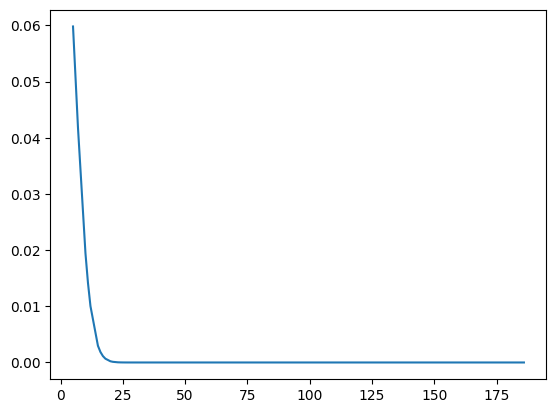

In [11]:
import matplotlib.pyplot as plt
energy_vals = sorted(list(set(energies)))
fig, ax = plt.subplots(1,1)
ax.plot(energy_vals, [boltzmanns[energies == x][0] for x in set(energies)])
# ax.set_yscale('log')